# Buck Converter — ROM vs Simscape Accuracy Benchmark

Pre-generated result files (no simulation in this notebook):

| File | Source | Execution time |
|---|---|---|
| `rom_vector1_output_765ms.mat` | Docker ROM | 765 ms |
| `rom_vector2_output_819ms.mat` | Docker ROM | 819 ms |
| `simscape_v1_dcdc_buck.mat` | MATLAB / Simscape | ~23.4 s |
| `simscape_v2_dcdc_buck.mat` | MATLAB / Simscape | ~22.6 s |

Compared signals (same physical names in ROM and Simscape):
`V_out` · `I_out` · `V_in` · `I_in`

## 0. Setup

In [1]:
import os
from pathlib import Path
import numpy as np
import scipy.io as sio
import h5py
import matplotlib.pyplot as plt

# ── locate benchmark folder ──────────────────────────────────────────────────
try:
    BENCH = Path(__file__).parent
except NameError:
    BENCH = Path(os.getcwd())
    if BENCH.name != 'benchmarks':
        for p in [BENCH] + list(BENCH.parents):
            if (p / 'benchmarks' / 'rom_outputs').exists():
                BENCH = p / 'benchmarks'
                break

ROM_V1 = BENCH / 'rom_outputs'      / 'rom_vector1_output_765ms.mat'
ROM_V2 = BENCH / 'rom_outputs'      / 'rom_vector2_output_819ms.mat'
SIM_V1 = BENCH / 'simscape_outputs' / 'simscape_v1_dcdc_buck.mat'
SIM_V2 = BENCH / 'simscape_outputs' / 'simscape_v2_dcdc_buck.mat'

# MATLAB wall-clock times encoded in the filenames (s)
MATLAB_TIME_V1_SEC = 23.384
MATLAB_TIME_V2_SEC = 22.606

for f in [ROM_V1, ROM_V2, SIM_V1, SIM_V2]:
    tag = 'OK' if f.exists() else 'MISSING'
    print(f'  [{tag}] {f.relative_to(BENCH)}')

  [OK] rom_outputs\rom_vector1_output_765ms.mat
  [OK] rom_outputs\rom_vector2_output_819ms.mat
  [OK] simscape_outputs\simscape_v1_dcdc_buck.mat
  [OK] simscape_outputs\simscape_v2_dcdc_buck.mat


## 1. Load Result Files

In [2]:
# Simscape signal mapping — same #refs# slot layout for both files
# (deterministic because both come from the same Simulink model with the same
#  logging order: V_in_set → V_in → Duty_Cyle → R_load → V_out → I_out → I_in)
SIM_REF_MAP = {
    'V_in_set':  '6b',
    'V_in':      'W',
    'Duty_Cyle': 'y',
    'R_load':    'kb',
    'V_out':     'rc',
    'I_out':     'Hb',
    'I_in':      'Nc',
}


def load_rom(mat_path):
    """Load Docker ROM result .mat (flat arrays via scipy.io)."""
    d = sio.loadmat(str(mat_path), squeeze_me=True)
    return {
        't':         d['t'].ravel(),
        'V_out':     d['V_out'].ravel(),
        'I_out':     d['I_out'].ravel(),
        'V_in':      d['V_in'].ravel(),
        'I_in':      d['I_in'].ravel(),
        'elapsed_s': float(d['elapsed_s']),
    }


def load_simscape(mat_path):
    """
    Load Simscape result .mat. Data fields are MATLAB timeseries objects
    (MCOS) — we read the raw float arrays from #refs# and reconstruct a
    uniform time grid (49981 samples over 250 ms ≈ 5 µs step).
    """
    out = {}
    with h5py.File(str(mat_path), 'r') as h:
        for name, ref_key in SIM_REF_MAP.items():
            out[name] = h[f'#refs#/{ref_key}'][:].ravel()
    N = len(out['V_out'])
    out['t'] = np.linspace(0.0, 0.25 * (N - 1) / N, N)   # ~5 µs step
    return out


print('Loading ROM results...')
rom_v1 = load_rom(ROM_V1)
rom_v2 = load_rom(ROM_V2)
print(f'  V1: {len(rom_v1["t"])} samples, elapsed={rom_v1["elapsed_s"]*1e3:.1f} ms')
print(f'  V2: {len(rom_v2["t"])} samples, elapsed={rom_v2["elapsed_s"]*1e3:.1f} ms')

print('\nLoading Simscape results...')
sim_v1 = load_simscape(SIM_V1)
sim_v2 = load_simscape(SIM_V2)
print(f'  V1: {len(sim_v1["t"])} samples, dt={(sim_v1["t"][1]-sim_v1["t"][0])*1e6:.2f} us')
print(f'  V2: {len(sim_v2["t"])} samples, dt={(sim_v2["t"][1]-sim_v2["t"][0])*1e6:.2f} us')

Loading ROM results...
  V1: 5000 samples, elapsed=765.4 ms
  V2: 5000 samples, elapsed=818.7 ms

Loading Simscape results...
  V1: 49981 samples, dt=5.00 us
  V2: 49981 samples, dt=5.00 us


## Accuracy Metrics

ROM and Simscape use the **same signal names** and physical units, so the
comparison is direct. Because they run at different time steps (ROM ≈ 50 µs,
Simscape ≈ 5 µs), the Simscape signal is interpolated to the ROM time grid
before computing per-sample error metrics.

In [3]:
SIGNALS = ['V_out', 'I_out', 'V_in', 'I_in']
UNITS   = {'V_out': 'V', 'I_out': 'A', 'V_in': 'V', 'I_in': 'A'}


def align_to_rom(rom, sim, sig):
    """Linearly interpolate the Simscape signal onto the ROM time grid."""
    return np.interp(rom['t'], sim['t'], sim[sig])


def compute_metrics(ref, pred):
    """RMSE, MaxErr, MAE — as % of reference peak-to-peak range."""
    err = ref - pred
    rng = np.ptp(ref) or (np.abs(ref).max() or 1.0)
    return {
        'RMSE_%':   np.sqrt(np.mean(err ** 2)) / rng * 100,
        'MaxErr_%': np.max(np.abs(err))         / rng * 100,
        'MAE_%':    np.mean(np.abs(err))        / rng * 100,
    }


MATLAB_TIMES = {'v1': MATLAB_TIME_V1_SEC, 'v2': MATLAB_TIME_V2_SEC}

for tag, label, rom, sim in [
    ('v1', 'Vector 1 — Step load',       rom_v1, sim_v1),
    ('v2', 'Vector 2 — Ramp Vin + sine', rom_v2, sim_v2),
]:
    print(f'\n{"="*65}')
    print(f'  {label}')
    print(f'{"="*65}')
    print(f'  {"Signal":10s}  {"RMSE %":>8s}  {"MaxErr %":>9s}  {"MAE %":>7s}  {"Range":>10s}')
    print(f'  {"-"*55}')
    for sig in SIGNALS:
        ref  = align_to_rom(rom, sim, sig)
        pred = rom[sig]
        m    = compute_metrics(ref, pred)
        rng  = np.ptp(ref)
        print(f'  {sig:10s}  {m["RMSE_%"]:8.2f}%  {m["MaxErr_%"]:9.2f}%  {m["MAE_%"]:7.2f}%  '
              f'{rng:8.2f} {UNITS[sig]}')
    print(f'  {"-"*55}')
    print(f'  Docker ROM   : {rom["elapsed_s"]*1e3:7.1f} ms')
    print(f'  MATLAB/Simscape: {MATLAB_TIMES[tag]:5.2f} s   →  speedup {MATLAB_TIMES[tag]/rom["elapsed_s"]:.0f}x')


  Vector 1 — Step load
  Signal        RMSE %   MaxErr %    MAE %       Range
  -------------------------------------------------------
  V_out           2.24%      58.20%     0.52%     36.25 V
  I_out           2.01%      37.10%     1.07%     11.88 A
  V_in            0.99%      10.20%     0.86%      0.00 V
  I_in           11.52%     285.08%     4.75%      6.19 A
  -------------------------------------------------------
  Docker ROM   :   765.4 ms
  MATLAB/Simscape: 23.38 s   →  speedup 31x

  Vector 2 — Ramp Vin + sine
  Signal        RMSE %   MaxErr %    MAE %       Range
  -------------------------------------------------------
  V_out           1.68%      26.84%     1.17%     19.95 V
  I_out           3.02%      25.50%     2.51%      3.99 A
  V_in            0.45%       1.79%     0.28%     20.00 V
  I_in           23.65%     680.05%     8.20%      2.07 A
  -------------------------------------------------------
  Docker ROM   :   818.7 ms
  MATLAB/Simscape: 22.61 s   →  speedup 

## Comparison Plots

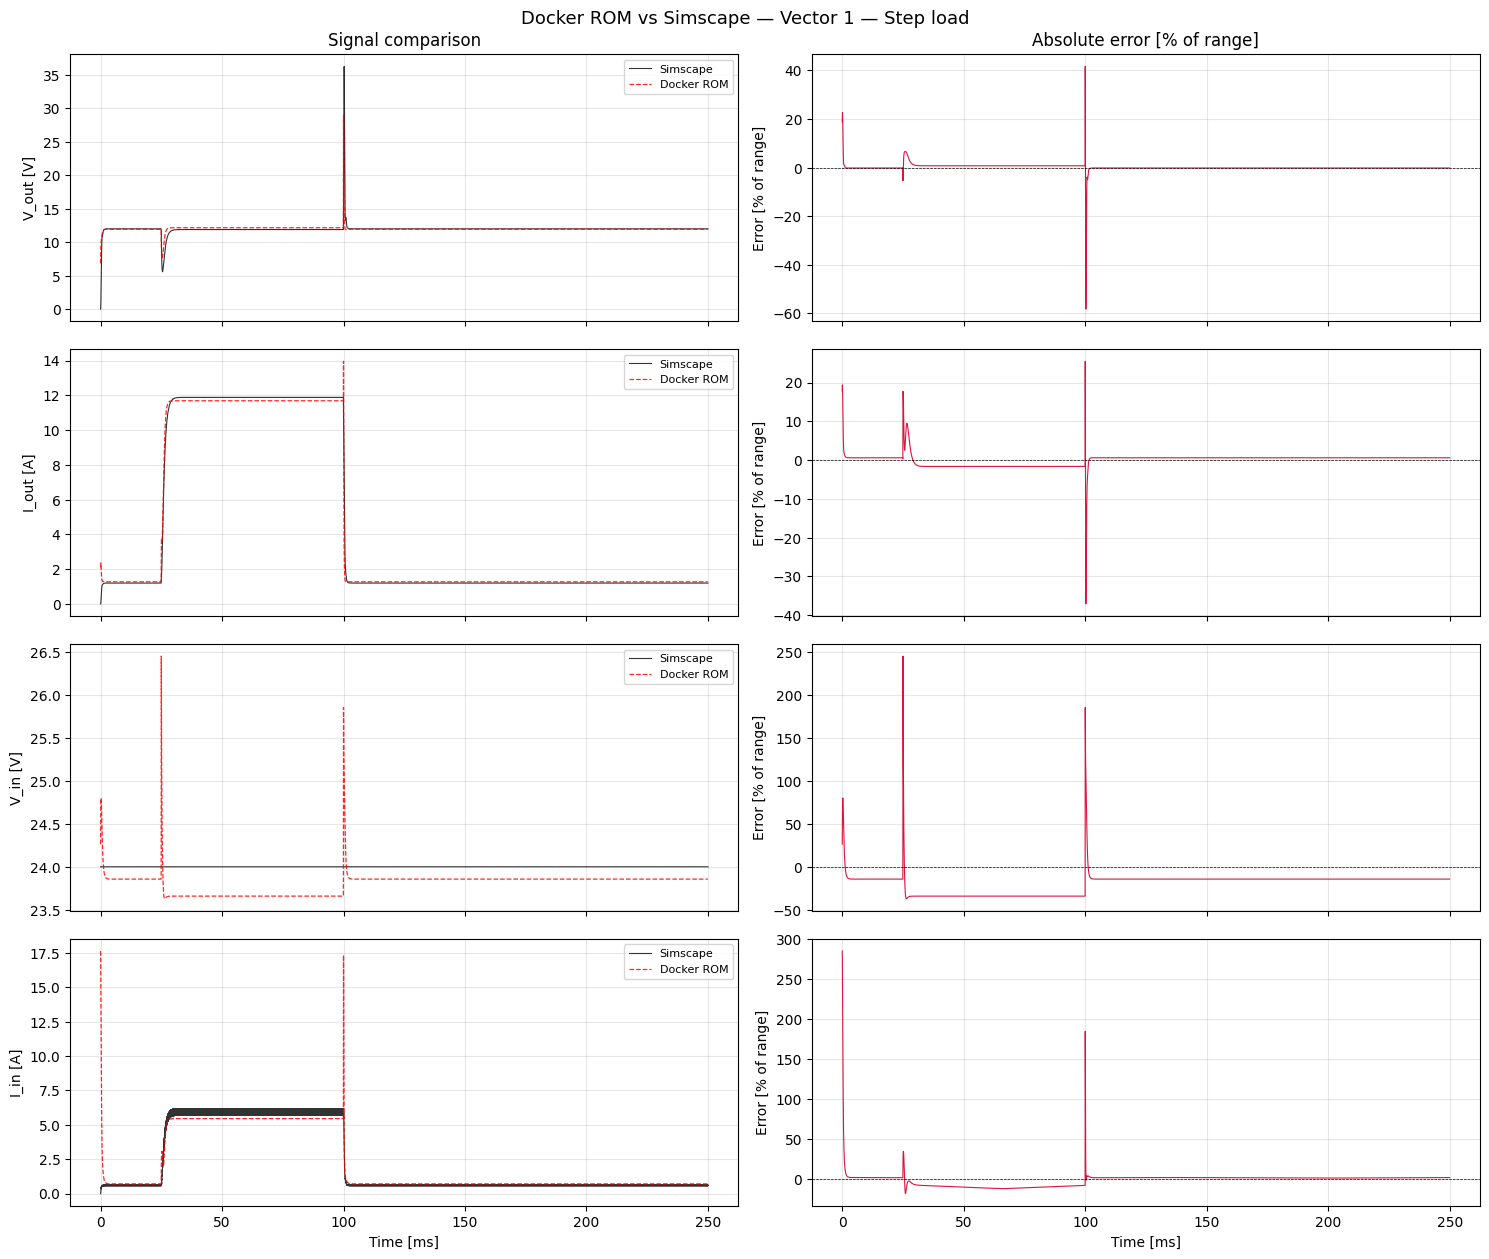

Saved -> d:\Projects\Simthetic\Repo\simthetic-public\benchmarks\benchmark_v1.png


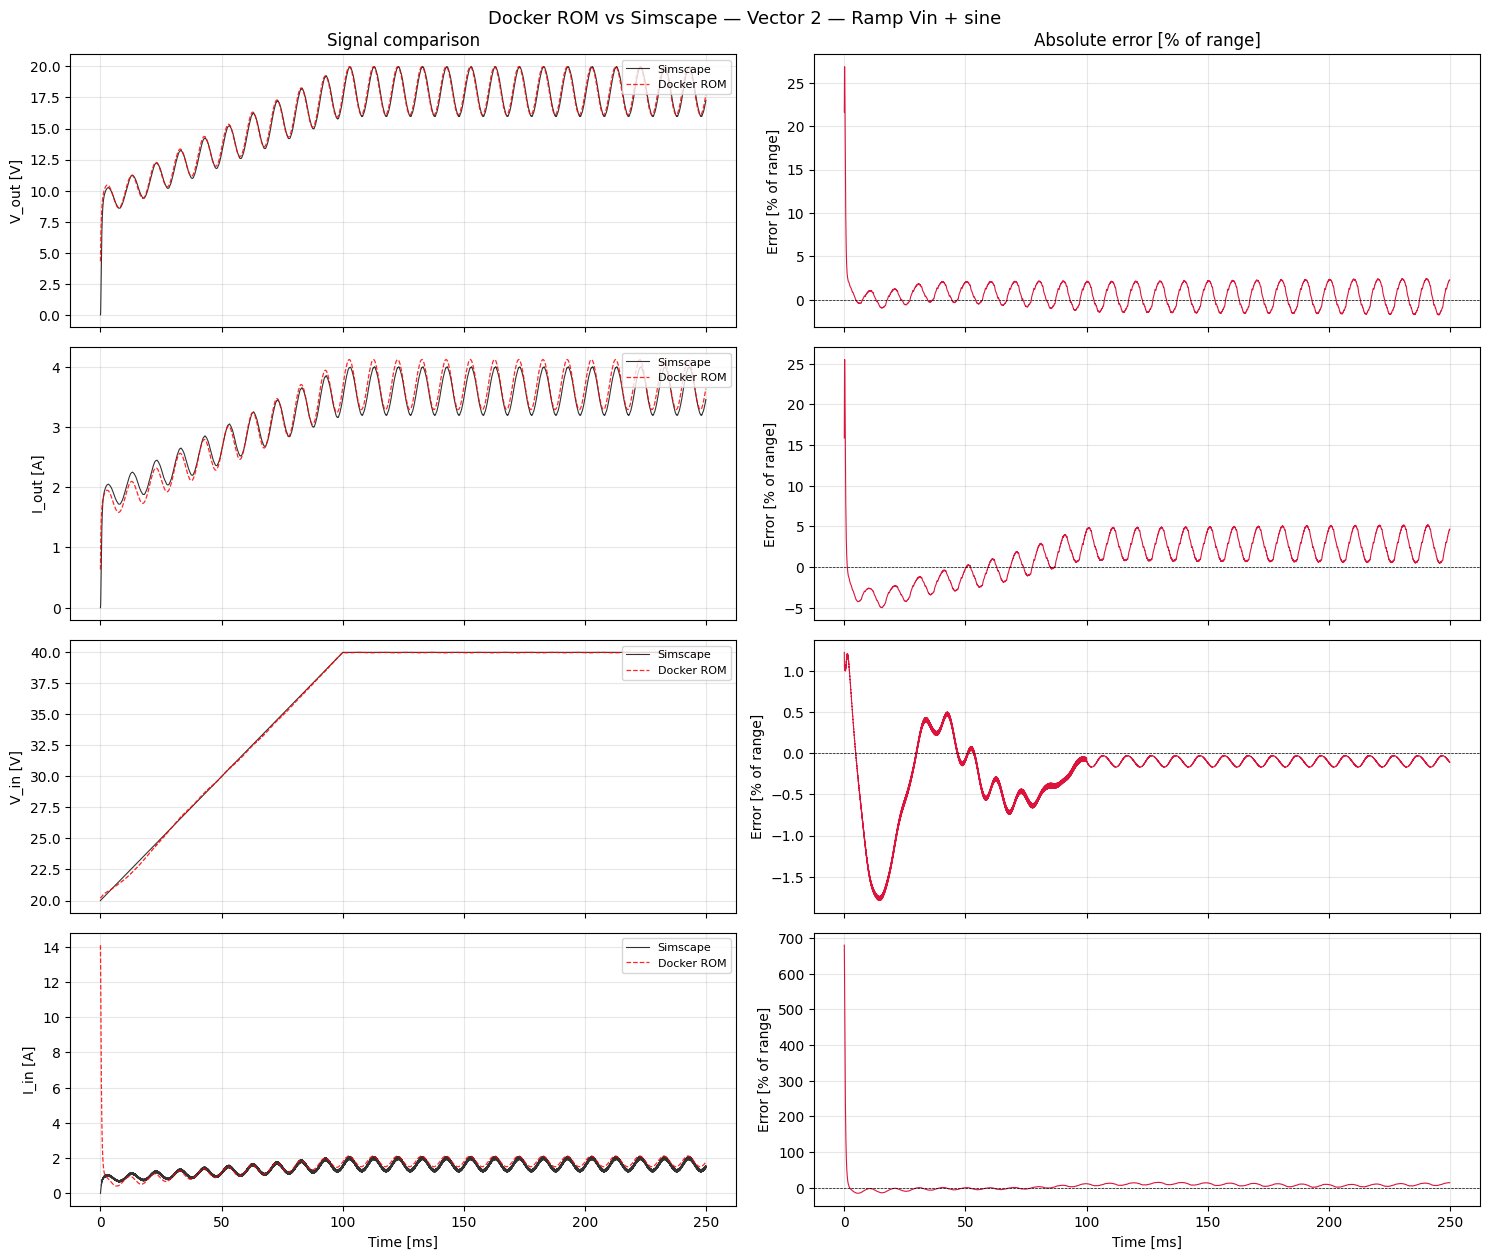

Saved -> d:\Projects\Simthetic\Repo\simthetic-public\benchmarks\benchmark_v2.png


In [4]:
def plot_comparison(tag, label, rom, sim, out_name):
    fig, axes = plt.subplots(len(SIGNALS), 2, figsize=(15, 3.2 * len(SIGNALS)), sharex='col')
    fig.suptitle(f'Docker ROM vs Simscape — {label}', fontsize=13)

    t_ms_rom = rom['t'] * 1e3
    t_ms_sim = sim['t'] * 1e3

    for i, sig in enumerate(SIGNALS):
        ref_on_rom = align_to_rom(rom, sim, sig)
        err  = rom[sig] - ref_on_rom
        rng  = np.ptp(ref_on_rom) or 1.0

        ax = axes[i, 0]
        ax.plot(t_ms_sim, sim[sig], 'k-',  lw=0.8, label='Simscape',  alpha=0.80)
        ax.plot(t_ms_rom, rom[sig], 'r--', lw=0.9, label='Docker ROM', alpha=0.85)
        ax.set_ylabel(f'{sig} [{UNITS[sig]}]')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)

        ax2 = axes[i, 1]
        ax2.plot(t_ms_rom, err / rng * 100, color='crimson', lw=0.8)
        ax2.axhline(0, color='k', lw=0.5, ls='--')
        ax2.set_ylabel('Error [% of range]')
        ax2.grid(True, alpha=0.3)

    for col in range(2):
        axes[-1, col].set_xlabel('Time [ms]')
    axes[0, 0].set_title('Signal comparison')
    axes[0, 1].set_title('Absolute error [% of range]')

    plt.tight_layout()
    out_file = BENCH / out_name
    plt.savefig(str(out_file), dpi=150)
    plt.show()
    print(f'Saved -> {out_file}')


plot_comparison('v1', 'Vector 1 — Step load',       rom_v1, sim_v1, 'benchmark_v1.png')
plot_comparison('v2', 'Vector 2 — Ramp Vin + sine', rom_v2, sim_v2, 'benchmark_v2.png')